In [70]:
import kagglehub
import os
from pathlib import Path
import matplotlib.pyplot as plt 
import random as rd

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\adamj.DESKTOP-RSU8KIQ\.cache\kagglehub\datasets\alessiocorrado99\animals10\versions\2


In [71]:
os.listdir(path)

['raw-img', 'translate.py']

In [72]:
raw_img = Path(path).joinpath("raw-img")
os.listdir(raw_img)

['cane',
 'cavallo',
 'elefante',
 'farfalla',
 'gallina',
 'gatto',
 'mucca',
 'pecora',
 'ragno',
 'scoiattolo']

In [73]:
raw_img_cats = os.listdir(Path(path).joinpath("raw-img").joinpath("gatto"))
raw_img_cats[-5:]

last_ten = raw_img_cats[-10:]
print(last_ten)

['nick-karvounis-538861-unsplash.jpg', 'OIP-BEqcWF77Te1ywfW1x-couAHaLG.jpeg', 'pacto-visual-199601-unsplash.jpg', 'paul-hanaoka-273394-unsplash.jpg', 'paul-hanaoka-280209-unsplash.jpg', 'q-aila-162475-unsplash.jpg', 'sam-burriss-378658-unsplash.jpg', 'sarah-dorweiler-128578-unsplash.jpg', 'xenia-bogarova-422041-unsplash.jpg', 'zoltan-tasi-437454-unsplash.jpg']


In [74]:
img_path = last_ten[9]
img_path

'zoltan-tasi-437454-unsplash.jpg'

nick-karvounis-538861-unsplash.jpg


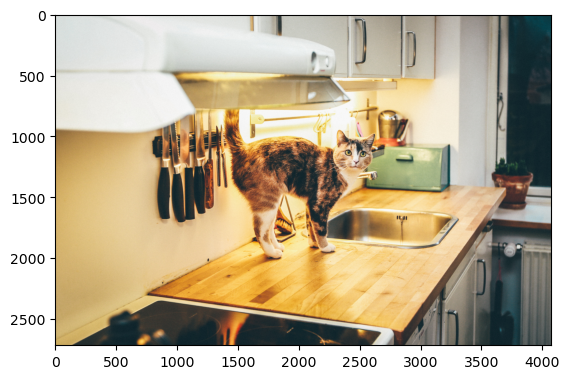

In [75]:
for i in range(1):
    print(last_ten[i])
    img = last_ten[i]
    plt.imshow(plt.imread(Path(path).joinpath("raw-img").joinpath("gatto").joinpath(img)))
    plt.show()

['sarah-dorweiler-128578-unsplash.jpg', 'xenia-bogarova-422041-unsplash.jpg', 'zoltan-tasi-437454-unsplash.jpg']
gatto


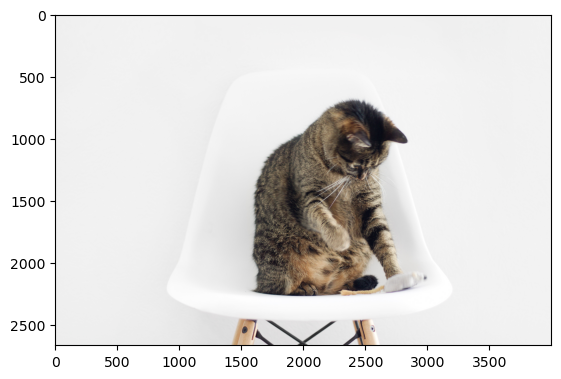

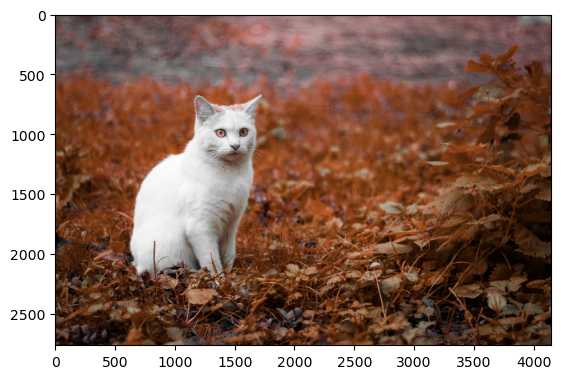

['OIP-_ZbJSvPHlAEP4YeyjtimhAHaJh.jpeg', 'OIP-_zMo5Tuf5UyDimOFh9gDMAHaHa.jpeg', 'OIP-__Yu1XH3iAC10OzGQFpC-AHaE8.jpeg']
cane


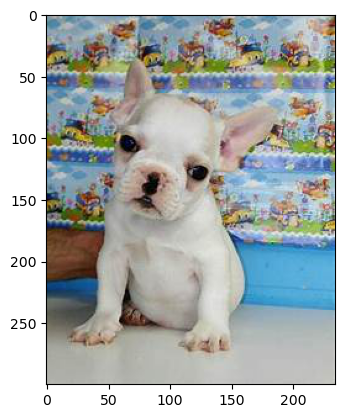

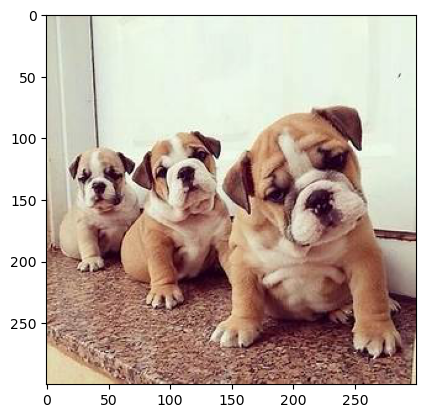

['OIP-_yOn1UTUWB7kWNmQOt93QAAAAA.jpeg', 'OIP-_z2ZnNHlWcjlKvdLpjxc2QHaC9.jpeg', 'OIP-_z8BmGoaFisnSQGFyl0QSgHaFj.jpeg']
farfalla


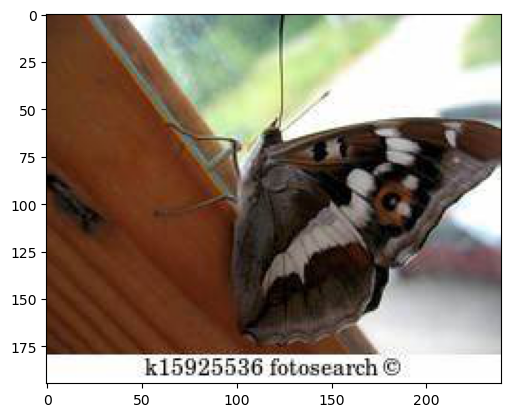

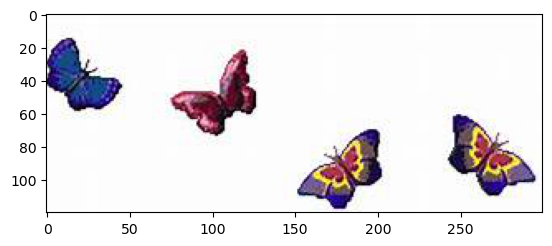

In [76]:
animals = ["gatto", "cane", "farfalla"]
for animal in animals:
    animal_path = Path(path).joinpath("raw-img").joinpath(animal)
    last = os.listdir(animal_path)[-3:]
    print(last)
    print(animal)
    for j in range (2):
        plt.imshow(plt.imread(animal_path.joinpath(last[j])))
        plt.show()

In [77]:
animal_list = os.listdir(raw_img)
animal_list
type(animal_list)
animal_list

['cane',
 'cavallo',
 'elefante',
 'farfalla',
 'gallina',
 'gatto',
 'mucca',
 'pecora',
 'ragno',
 'scoiattolo']

In [78]:
raw_img_path = Path(path).joinpath("raw-img")
for animal in animal_list:
    amount = len(os.listdir(raw_img_path.joinpath(animal)))
    print(f"{animal}:{amount}")

cane:4863
cavallo:2623
elefante:1446
farfalla:2112
gallina:3098
gatto:1668
mucca:1866
pecora:1820
ragno:4821
scoiattolo:1862


In [79]:
gattos = os.listdir(raw_img_path.joinpath("gatto"))
rd.shuffle(gattos)
split_point = int(len(gattos) * 0.8)
train = gattos[:split_point]
train
test = gattos[split_point:]
print(f"train {len(train)} test {len(test)} both {len(gattos)}")

train 1334 test 334 both 1668


In [80]:
my_dict = {}
train_pairs = []
val_pairs = []

for animal in animal_list:
    animal_file = os.listdir(raw_img_path.joinpath(animal))
    rd.shuffle(animal_file)
    split_point = int(len(animal_file)*0.8)
    train_animal = animal_file[:split_point]
    val_animal = animal_file[split_point:]
   
    my_dict[animal] = {
                    "train" : train_animal,
                    "val" : val_animal, 
                    "both" : animal_file
                    }

    for file in train_animal:
        full_path = raw_img_path.joinpath(animal, file)
        train_pairs.append((animal, full_path))
    for file in val_animal:
        full_path = raw_img_path.joinpath(animal, file)
        val_pairs.append((animal, full_path))

#    print(f"{animal} train {len(train_animal)} val {len(val_animal)} both {len(animal_file)}")
train_pairs[:5]
len(train_pairs) + len(val_pairs)


26179

In [81]:
label_map = {}
for idx, animal in enumerate(animal_list):
    label_map[animal] = idx
print(label_map)

reverse_label_map = {}  
for animal, idx in label_map.items():
    reverse_label_map[idx] = animal
print(reverse_label_map)

{'cane': 0, 'cavallo': 1, 'elefante': 2, 'farfalla': 3, 'gallina': 4, 'gatto': 5, 'mucca': 6, 'pecora': 7, 'ragno': 8, 'scoiattolo': 9}
{0: 'cane', 1: 'cavallo', 2: 'elefante', 3: 'farfalla', 4: 'gallina', 5: 'gatto', 6: 'mucca', 7: 'pecora', 8: 'ragno', 9: 'scoiattolo'}


In [82]:
train_encoded = []

for i in train_pairs:
    label_mapped = label_map[i[0]]
    train_encoded.append((i[1], label_mapped))

train_encoded[1][1]

0

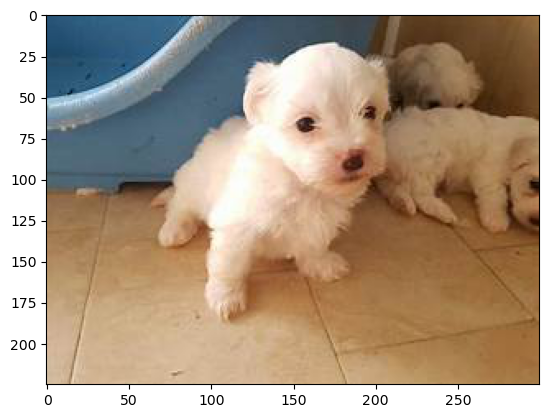

0 cane


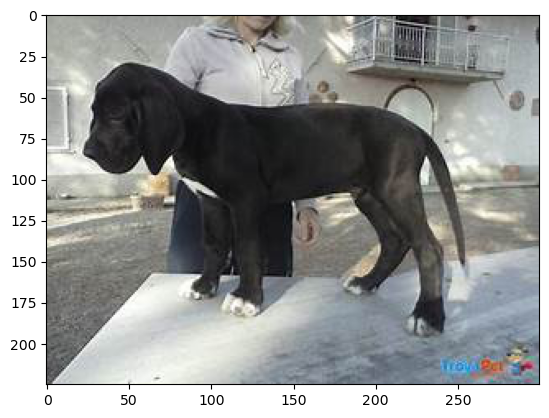

0 cane


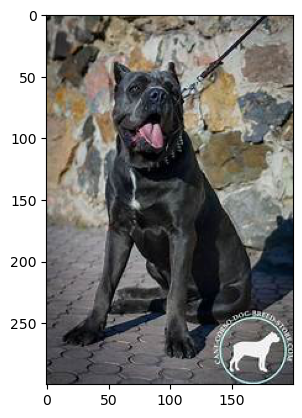

0 cane


In [83]:
for i in range(3):
    img = train_encoded[i][0]
    group = train_encoded[i][1]
    plt.imshow(plt.imread(img))
    plt.show()
    print(group, reverse_label_map[group])

In [84]:
import torchvision as tv
from torchvision import transforms
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [85]:
img = Image.open(train_encoded[0][0])
print(img)
print(img.size)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
img_transformed = transform(img)
print(img_transformed.shape)

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=300x225 at 0x20E4300A910>
(300, 225)
torch.Size([3, 224, 224])


In [86]:
class AnimalsDataset(Dataset):
    def __init__(self, data):
        self.data = data
        self.transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor()
        ])
    
    def __len__(self):
        return len(self.data)
    
 
    def __getitem__(self, idx):
        image_path, label = self.data[idx]
        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)
        return image, label

In [87]:
train_dataset = AnimalsDataset(train_encoded)

img, label = train_dataset[0]
print(img.shape)
print(label)
print(reverse_label_map[label])

torch.Size([3, 128, 128])
0
cane


In [88]:
for i in range(3):
    img , label = train_dataset[i]
    print(img.shape, label, reverse_label_map[label])

torch.Size([3, 128, 128]) 0 cane
torch.Size([3, 128, 128]) 0 cane
torch.Size([3, 128, 128]) 0 cane


In [100]:
from torch.utils.data import Subset

indices = torch.randperm(len(train_dataset))[:1000]
small_train_dataset = Subset(train_dataset, indices)
train_loader = DataLoader(small_train_dataset, batch_size=32, shuffle=True)
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)
print(labels)

torch.Size([32, 3, 128, 128])
torch.Size([32])
tensor([7, 1, 4, 0, 4, 8, 8, 7, 7, 6, 0, 3, 1, 6, 7, 4, 8, 8, 1, 2, 1, 4, 9, 8,
        4, 7, 9, 7, 8, 1, 5, 7])


In [101]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*16*16, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [102]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(animal_list)
model = SimpleCNN(num_classes).to(device)

images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

outputs = model(images)
print(outputs.shape)

torch.Size([32, 10])


In [103]:
preds = outputs.argmax(dim=1)
print(preds.shape)
print(preds[:5])
print(labels[:5])

torch.Size([32])
tensor([1, 1, 1, 1, 1], device='cuda:0')
tensor([0, 5, 0, 0, 0], device='cuda:0')


In [104]:
correct = (preds == labels).sum().item()
total = labels.size(0)

print("correct: ", correct )
print("total: ", total)
print("Accuracy: ", correct / total)

correct:  2
total:  32
Accuracy:  0.0625


In [105]:
criterion = nn.CrossEntropyLoss()
loss = criterion(outputs, labels)
print("Loss: ", loss.item())
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss.backward()

Loss:  2.2972826957702637


In [106]:
optimizer.step()
optimizer.zero_grad()

In [107]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

optimizer.zero_grad()

outputs = model(images)
loss_before = criterion(outputs, labels)

loss_before.backward()
optimizer.step()

outputs_after = model(images)
loss_after = criterion(outputs_after, labels)

print("Loss before:", loss_before.item())
print("Loss after: ", loss_after.item())

Loss before: 2.2910046577453613
Loss after:  2.1995787620544434


In [108]:
correct = (preds == labels).sum().item()
total = labels.size(0)

print("correct: ", correct )
print("total: ", total)
print("Accuracy: ", correct / total)

correct:  4
total:  32
Accuracy:  0.125


In [109]:
for i, (images, labels) in enumerate(train_loader):
    
    images = images.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    if i % 10 == 0:
        print(f"Batch {i}, Loss: {loss.item()}")

print("one epoch done")

Batch 0, Loss: 2.2820746898651123
Batch 10, Loss: 2.221947431564331
Batch 20, Loss: 2.292079448699951
Batch 30, Loss: 2.291005849838257
one epoch done


In [110]:
print("Dataset size:", len(train_dataset))
print("Number of batches:", len(train_loader))
print("Batch size:", train_loader.batch_size)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Dataset size: 20938
Number of batches: 32
Batch size: 32
Device: cuda


In [ ]:
num_epochs = 5

for epoch in range(num_epochs):

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss}")
